# **Project : Credit Card Defaulters**

Import libraries

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

Load dataset

In [2]:
df=pd.read_excel("/content/drive/MyDrive/Datasets/default of credit card clients.xls")

**Data Manupulation**

In [3]:
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [4]:
df.tail()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
29995,220000,1,3,1,39,0,0,0,0,0,...,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29996,150000,1,3,2,43,-1,-1,-1,-1,0,...,8979,5190,0,1837,3526,8998,129,0,0,0
29997,30000,1,2,2,37,4,3,2,-1,0,...,20878,20582,19357,0,0,22000,4200,2000,3100,1
29998,80000,1,3,1,41,1,-1,0,0,0,...,52774,11855,48944,85900,3409,1178,1926,52964,1804,1
29999,50000,1,2,1,46,0,0,0,0,0,...,36535,32428,15313,2078,1800,1430,1000,1000,1000,1


In [5]:
df.columns

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object')

In [6]:
df.size

720000

In [7]:
df.shape

(30000, 24)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   LIMIT_BAL                   30000 non-null  int64
 1   SEX                         30000 non-null  int64
 2   EDUCATION                   30000 non-null  int64
 3   MARRIAGE                    30000 non-null  int64
 4   AGE                         30000 non-null  int64
 5   PAY_0                       30000 non-null  int64
 6   PAY_2                       30000 non-null  int64
 7   PAY_3                       30000 non-null  int64
 8   PAY_4                       30000 non-null  int64
 9   PAY_5                       30000 non-null  int64
 10  PAY_6                       30000 non-null  int64
 11  BILL_AMT1                   30000 non-null  int64
 12  BILL_AMT2                   30000 non-null  int64
 13  BILL_AMT3                   30000 non-null  int64
 14  BILL_A

Calculate null value

In [9]:
df.isnull().sum()

,0
LIMIT_BAL,0
SEX,0
EDUCATION,0
MARRIAGE,0
AGE,0
PAY_0,0
PAY_2,0
PAY_3,0
PAY_4,0
PAY_5,0


Calculate duplicate value

In [10]:
df.duplicated().sum()

np.int64(35)

Drop duplicate

In [11]:
df.drop_duplicates(inplace=True)

Summary of data

In [12]:
df.describe()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000,...,29965.000000,29965.000000,29965.000000,29965.000000,2.996500e+04,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000
mean,167442.005006,1.603738,1.853629,1.551877,35.487969,-0.016753,-0.131854,-0.164392,-0.218922,-0.264509,...,43313.329885,40358.334390,38917.012281,5670.099316,5.927983e+03,5231.688837,4831.617454,4804.897047,5221.498014,0.221258
std,129760.135222,0.489128,0.790411,0.521997,9.219459,1.123492,1.196322,1.195878,1.168175,1.132220,...,64353.514373,60817.130623,59574.147742,16571.849467,2.305346e+04,17616.361124,15674.464538,15286.372298,17786.976864,0.415101
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2360.000000,1787.000000,1262.000000,1000.000000,8.500000e+02,390.000000,300.000000,261.000000,131.000000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,19081.000000,18130.000000,17124.000000,2102.000000,2.010000e+03,1804.000000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,54601.000000,50247.000000,49252.000000,5008.000000,5.000000e+03,4512.000000,4016.000000,4042.000000,4000.000000,0.000000
max,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.000000,621000.000000,426529.000000,528666.000000,1.000000


In [13]:
df.rename(columns={'default payment next month':'DEFAULT'}, inplace=True)
df.rename(columns={'PAY_0': 'PAY_1'}, inplace=True)

In [14]:
# Fix categorical values
df['EDUCATION'] = df['EDUCATION'].replace({0:4, 5:4, 6:4})
df['MARRIAGE'] = df['MARRIAGE'].replace({0:3})

**Visualization**

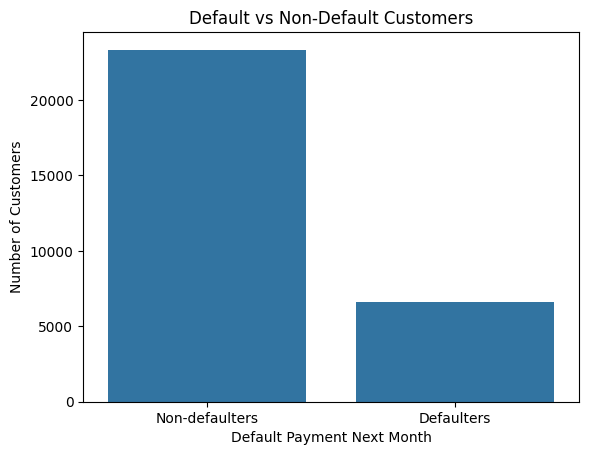

In [15]:
#count plot
sns.countplot(x='DEFAULT', data=df)
plt.title("Default vs Non-Default Customers")
plt.xticks([0,1],['Non-defaulters', 'Defaulters'])
plt.xlabel("Default Payment Next Month")
plt.ylabel("Number of Customers")
plt.show()

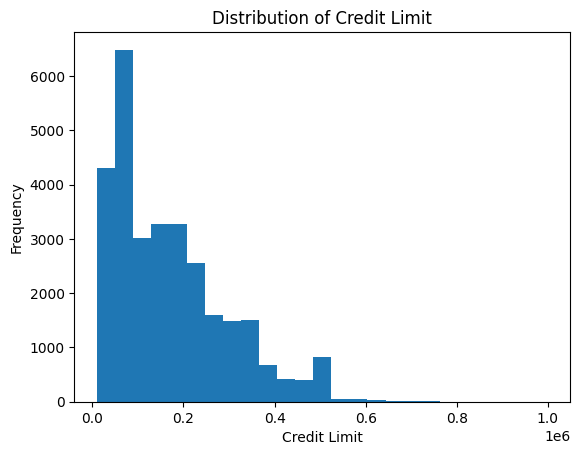

In [16]:

#histogram
#credit limit
plt.hist(df['LIMIT_BAL'], bins=25)
plt.title("Distribution of Credit Limit")
plt.xlabel("Credit Limit")
plt.ylabel("Frequency")
plt.show()

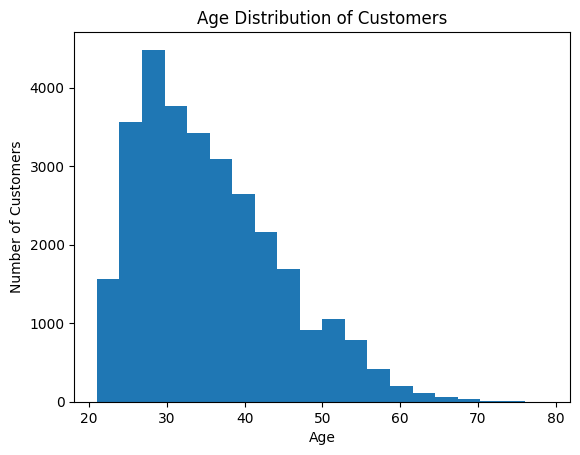

In [17]:
#age distribution
plt.hist(df['AGE'], bins=20)
plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

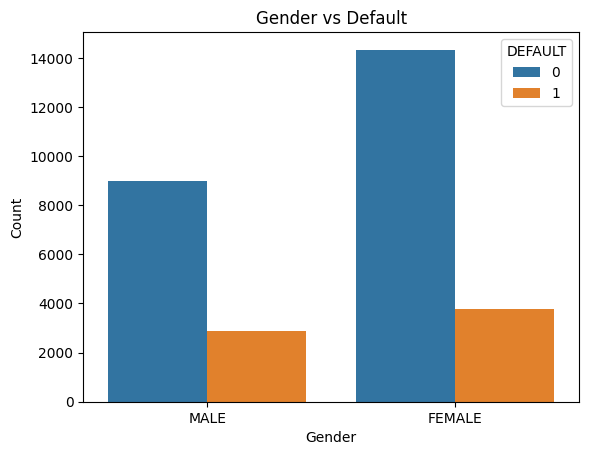

In [18]:
#gender vs default
sns.countplot(x='SEX', hue='DEFAULT', data=df)
plt.xticks([0,1],['MALE', 'FEMALE'])
plt.title("Gender vs Default")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

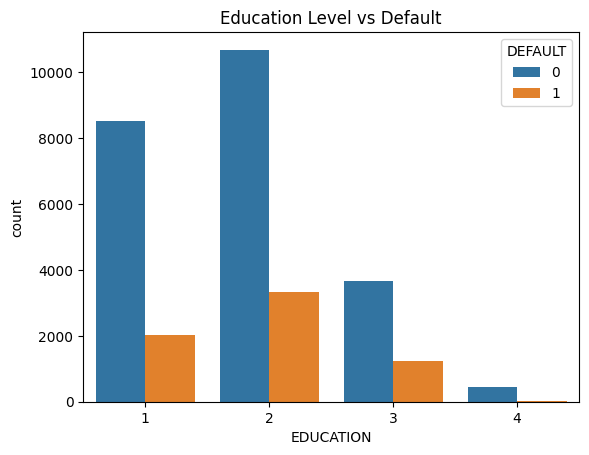

In [19]:
sns.countplot(x='EDUCATION', hue='DEFAULT', data=df)
plt.title("Education Level vs Default")
plt.show()

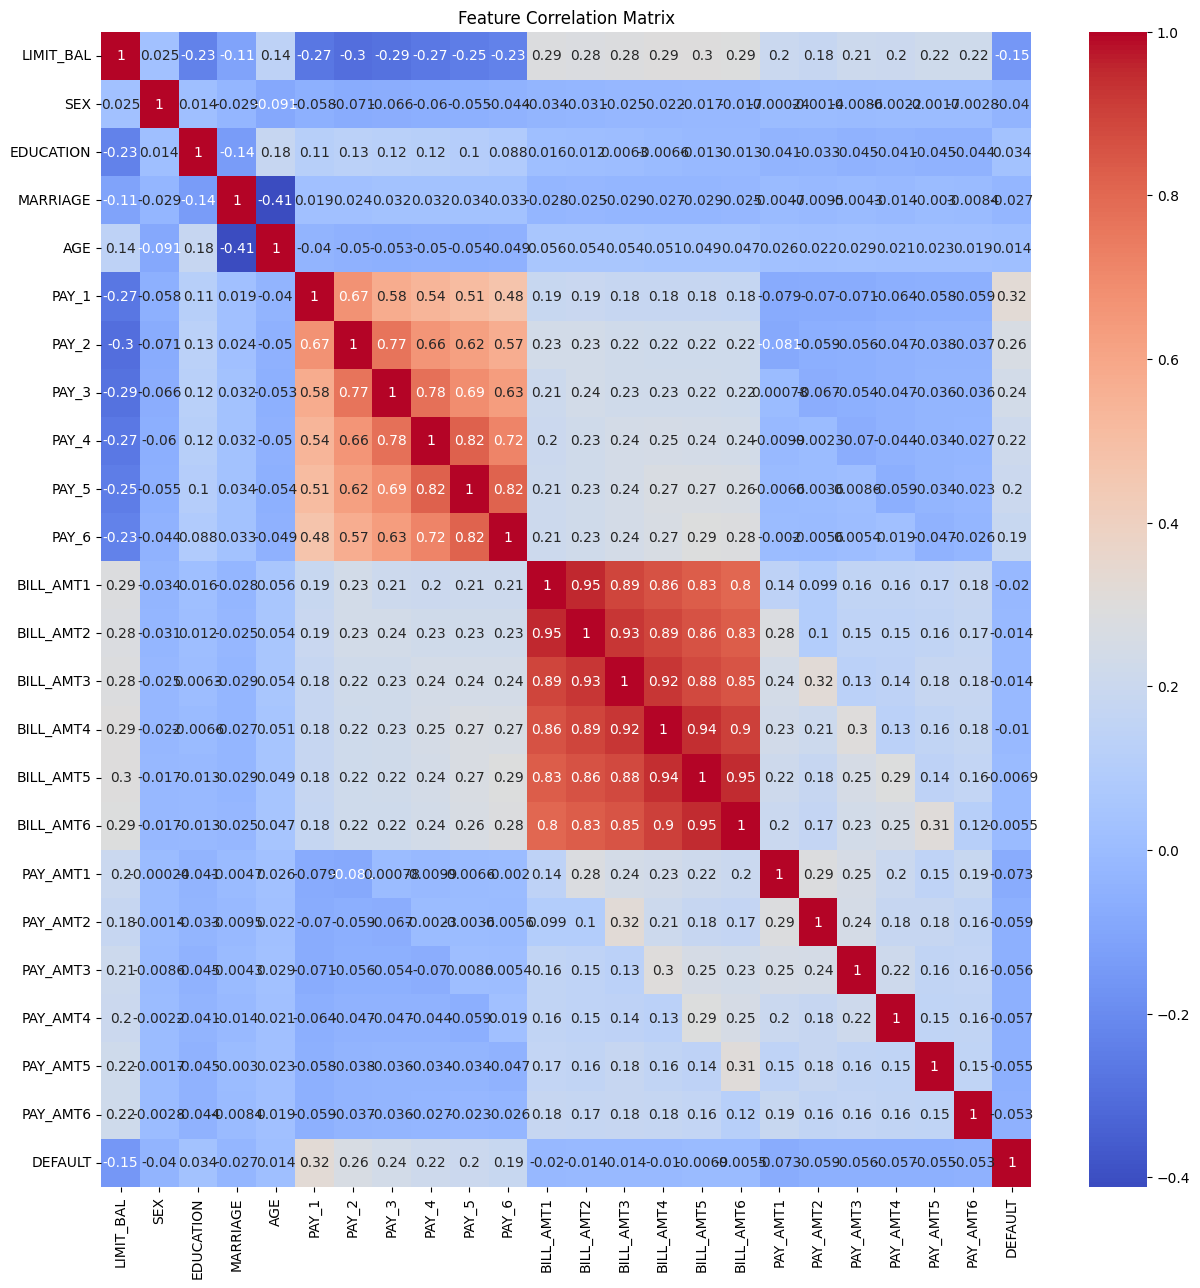

In [20]:
#heat map
figure=plt.figure(figsize=(15,15))
corr = df.corr()

sns.heatmap(corr, cmap='coolwarm',annot=True)
plt.title("Feature Correlation Matrix")
plt.show()

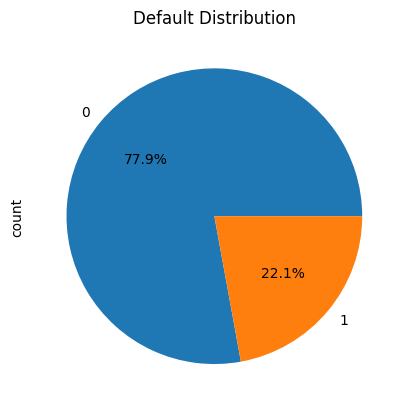

In [21]:
#pie chart
df['DEFAULT'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Default Distribution")
plt.show()

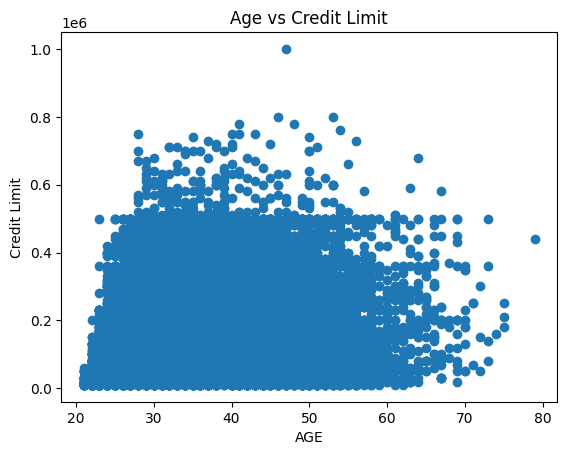

In [22]:
#scatterplot
plt.scatter(df['AGE'], df['LIMIT_BAL'])
plt.xlabel("AGE")
plt.ylabel("Credit Limit")
plt.title("Age vs Credit Limit")
plt.show()

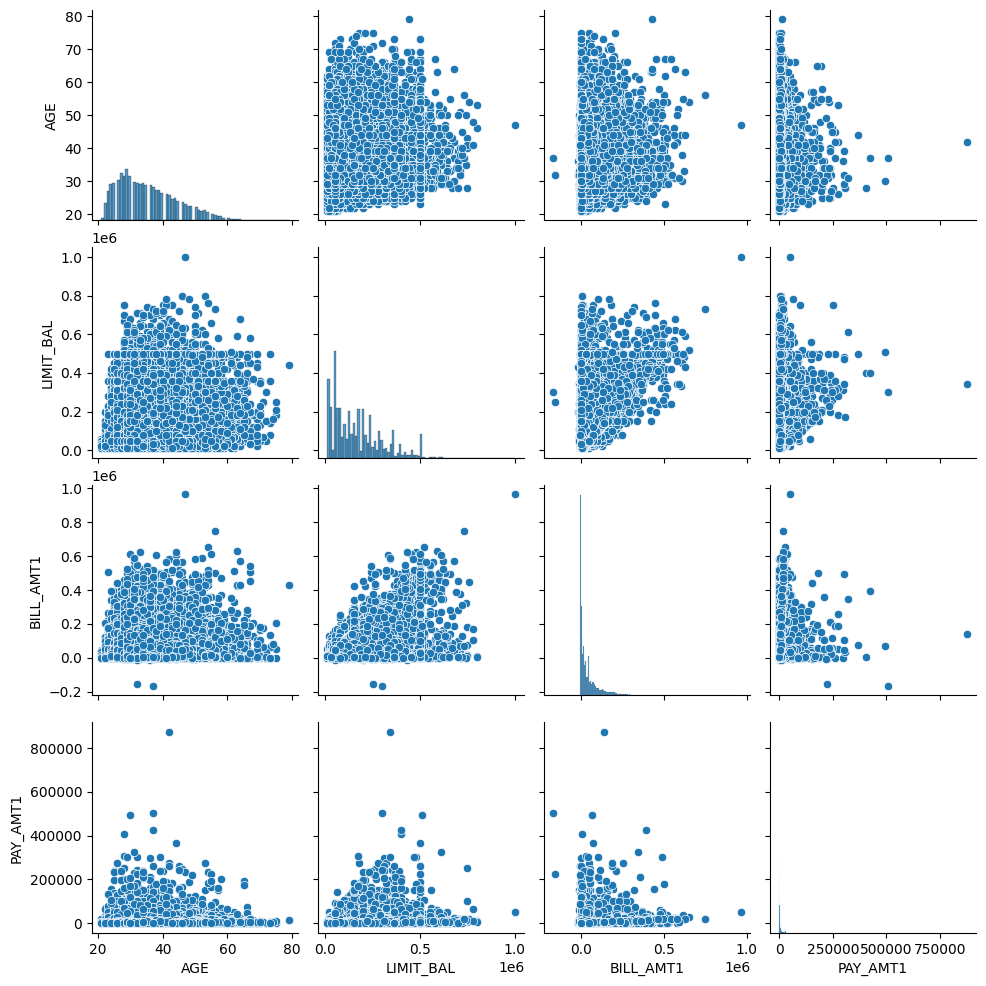

In [23]:
#pair plot
sns.pairplot(df[['AGE','LIMIT_BAL','BILL_AMT1','PAY_AMT1']])
plt.show()

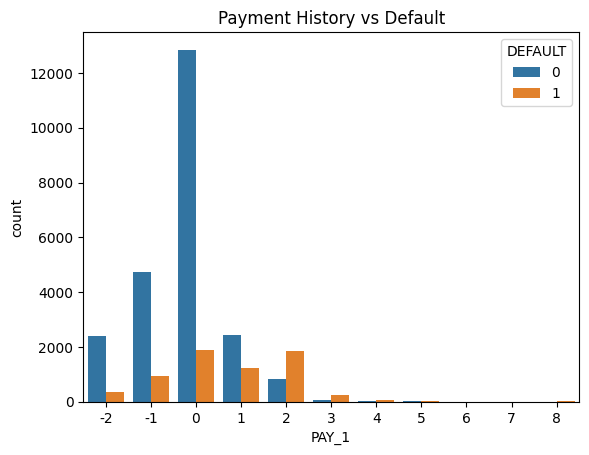

In [24]:
#count plot
sns.countplot(x='PAY_1', hue='DEFAULT', data=df)
plt.title("Payment History vs Default")
plt.show()

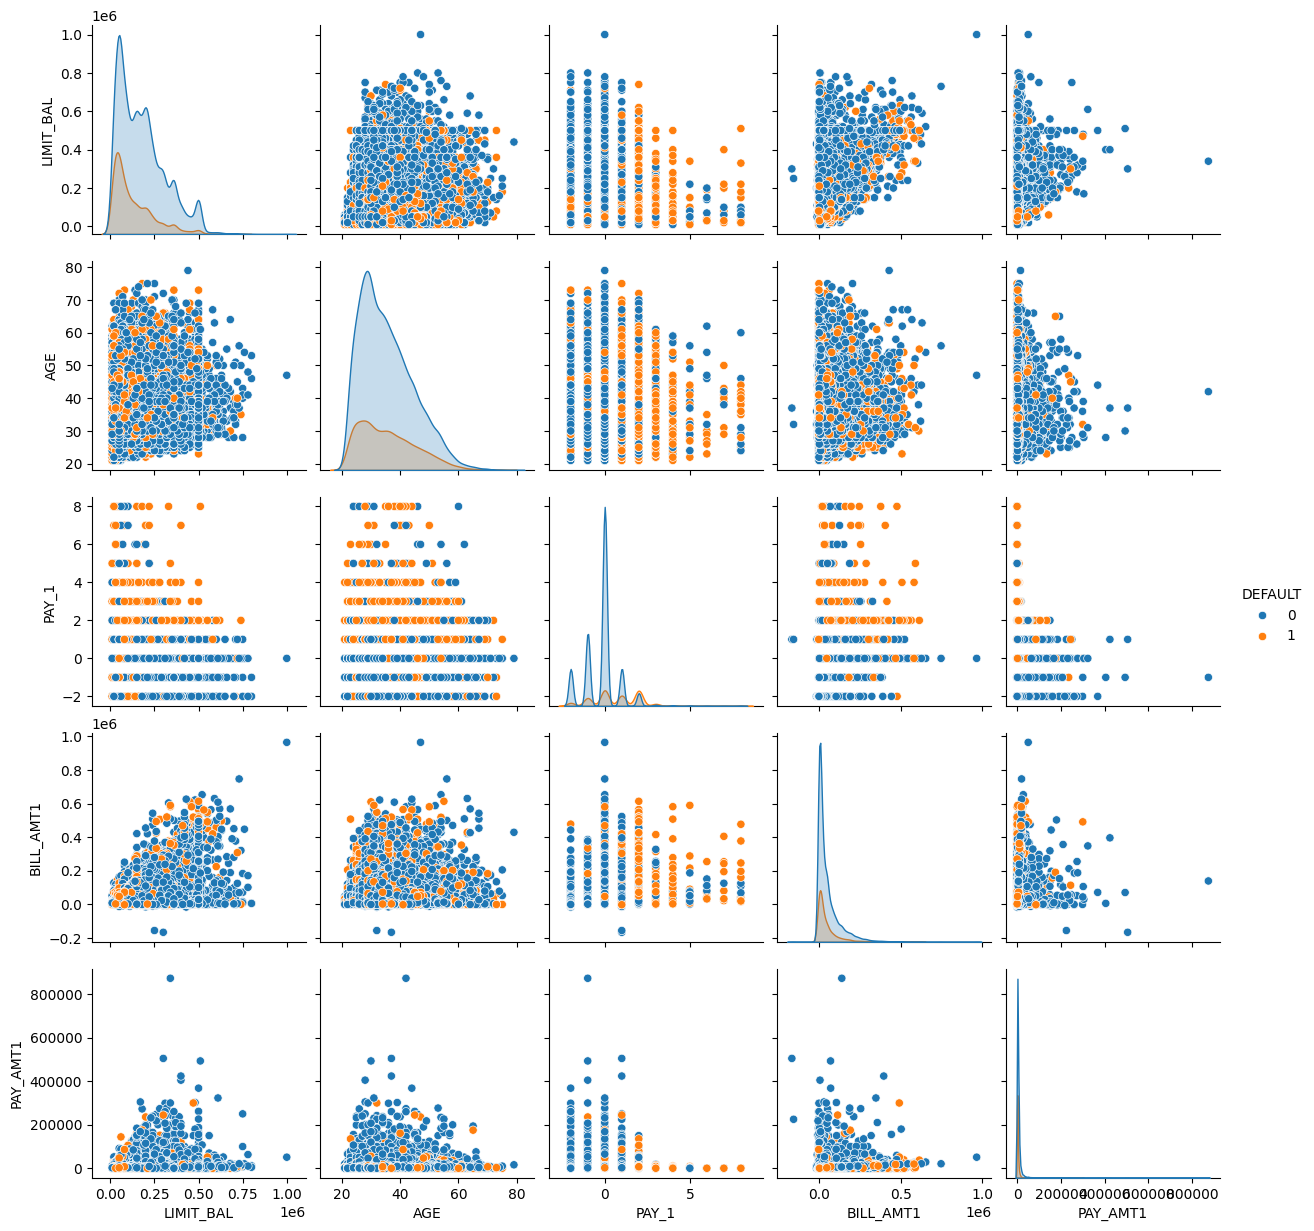

In [25]:
sns.pairplot(df[['LIMIT_BAL','AGE','PAY_1','BILL_AMT1',
                 'PAY_AMT1','DEFAULT']],
             hue='DEFAULT')
plt.show()

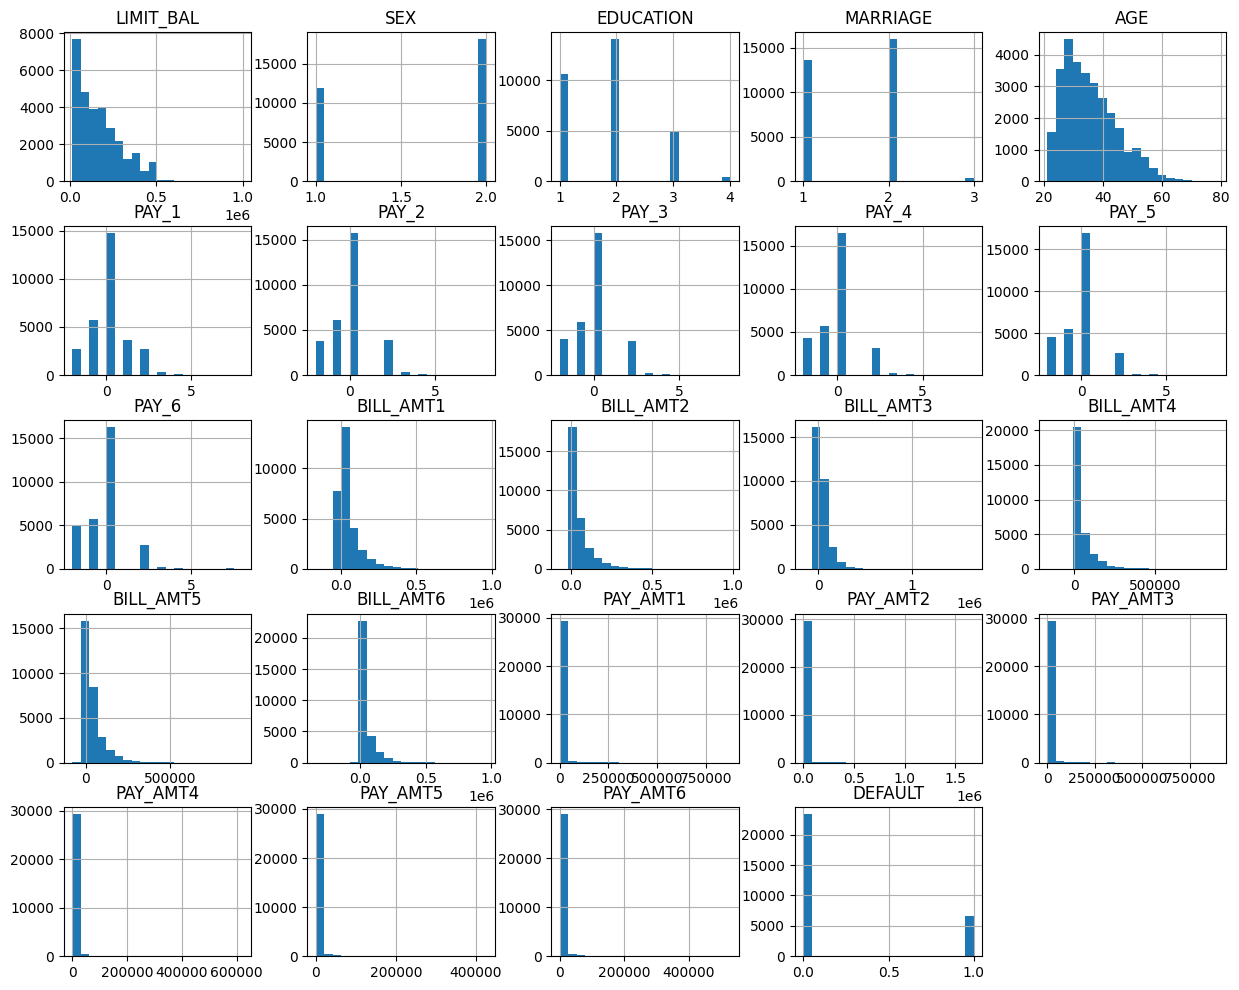

In [26]:
#HISTOGRAM
df.hist(figsize=(15, 12), bins=20)
plt.show()

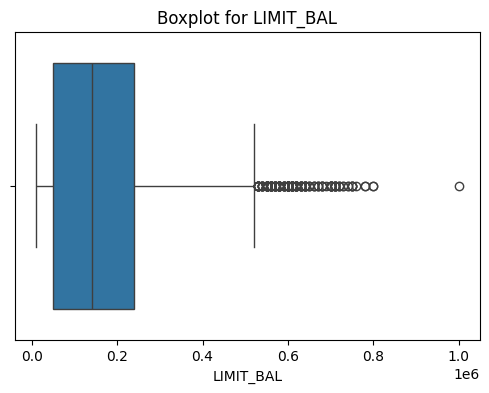

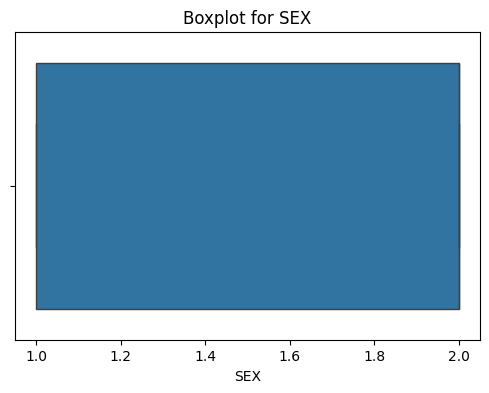

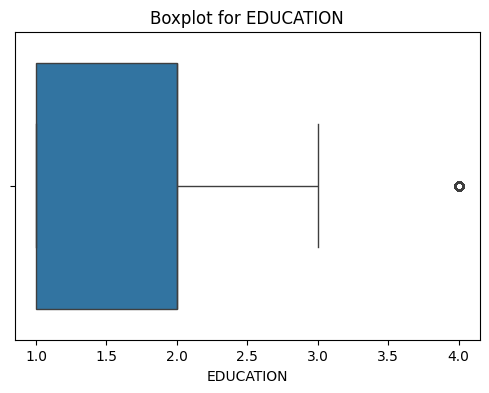

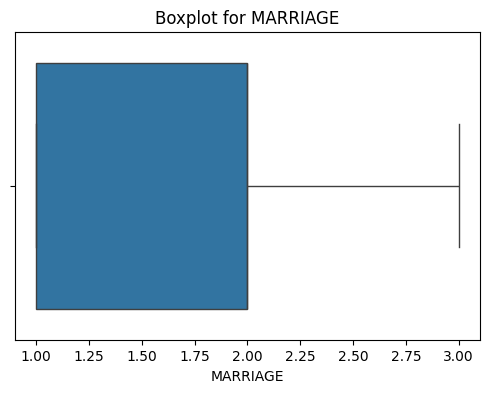

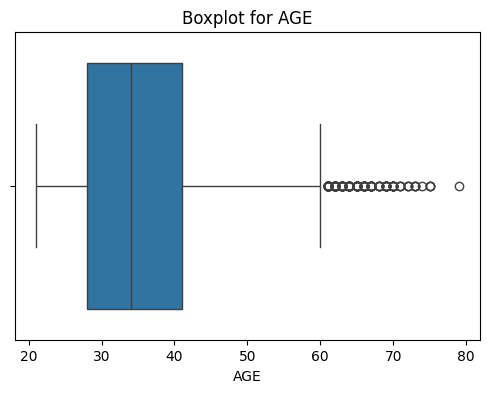

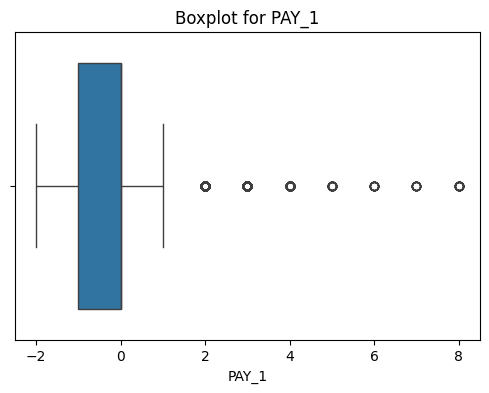

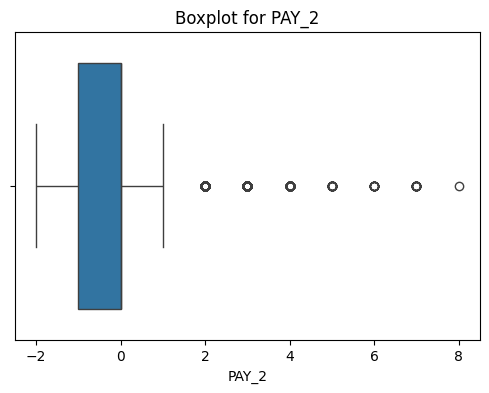

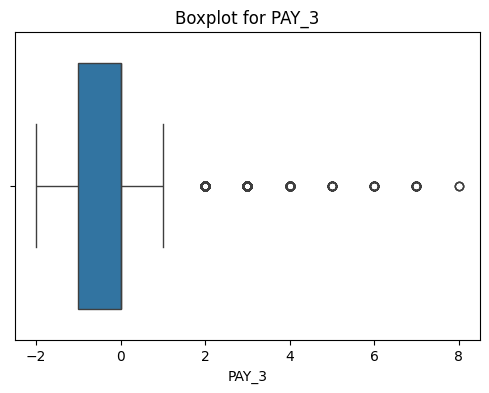

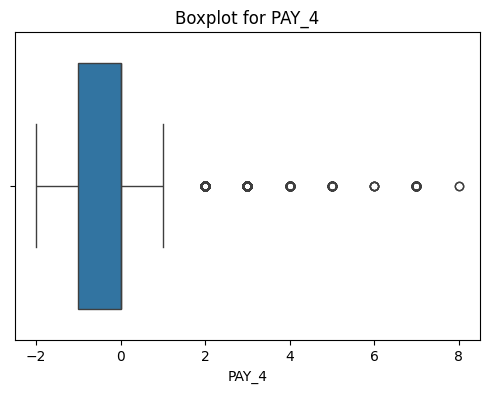

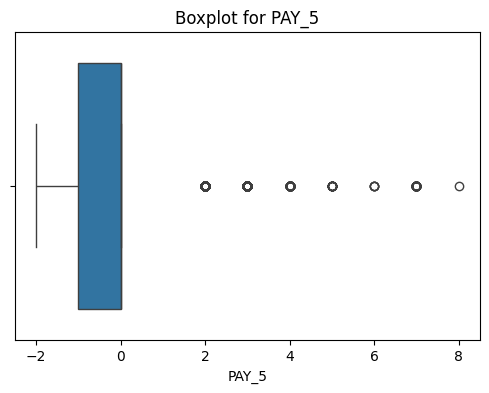

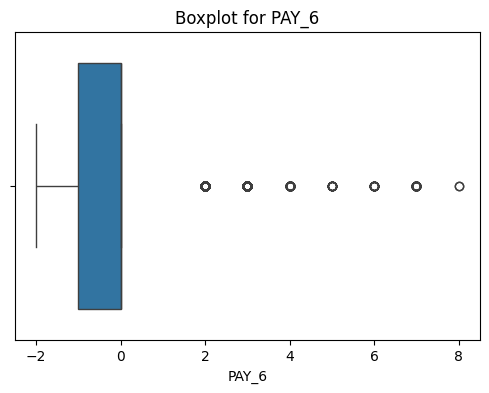

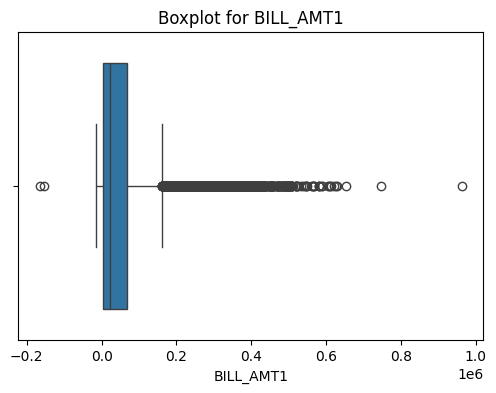

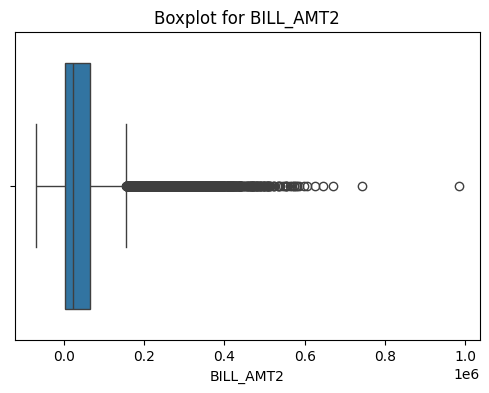

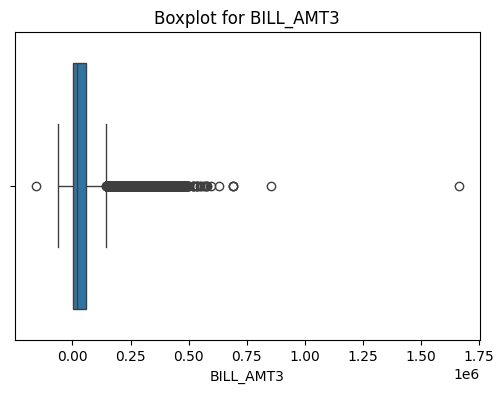

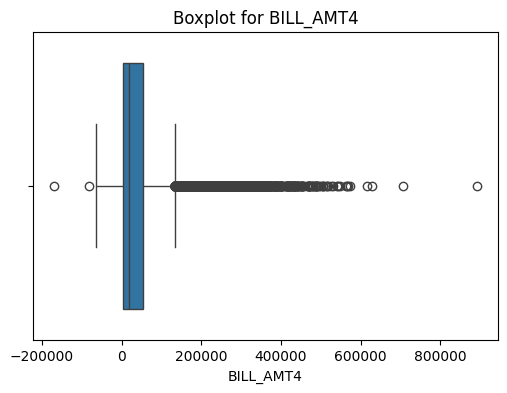

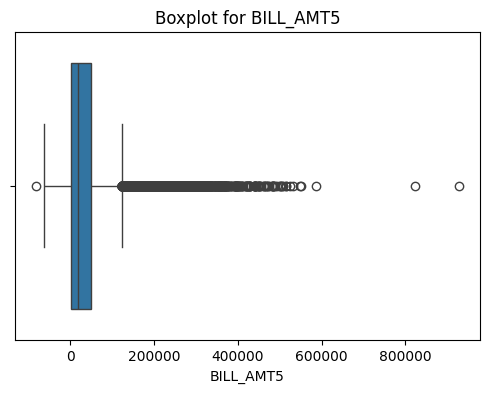

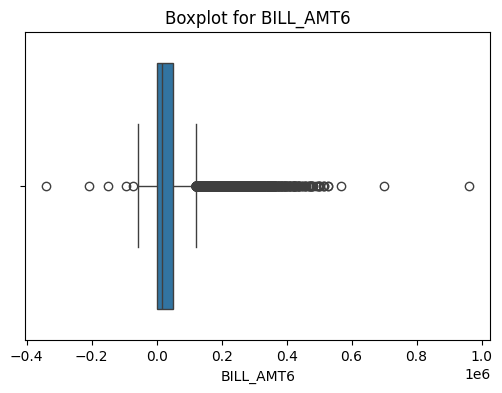

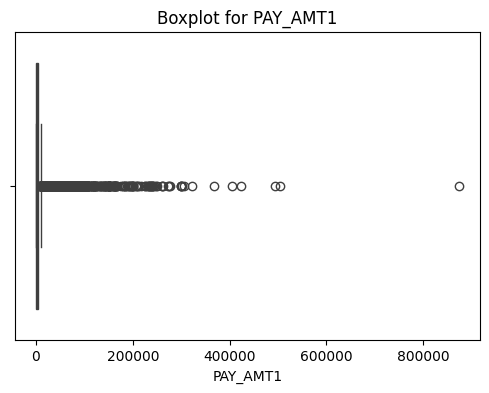

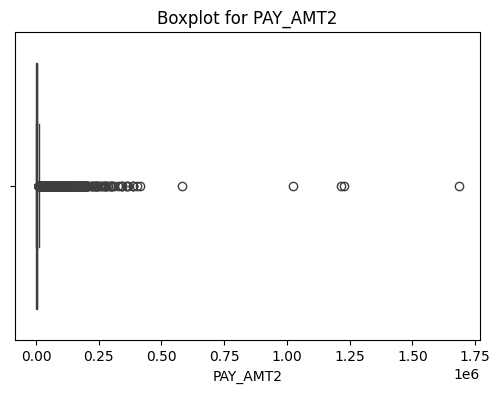

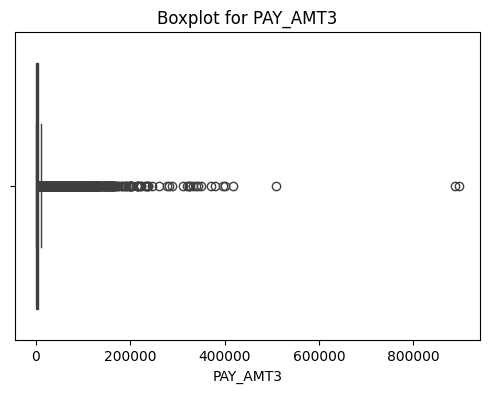

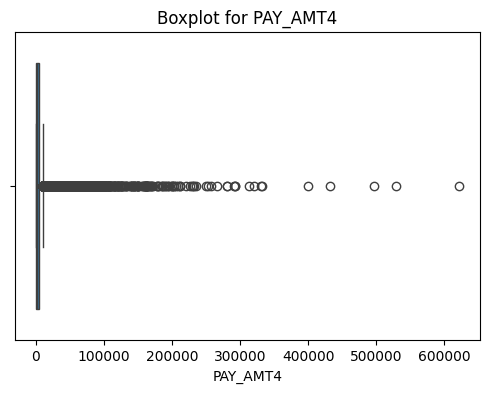

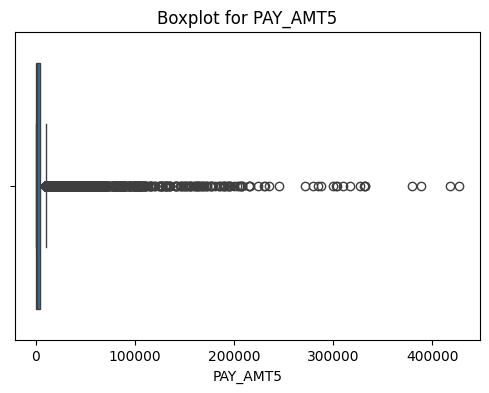

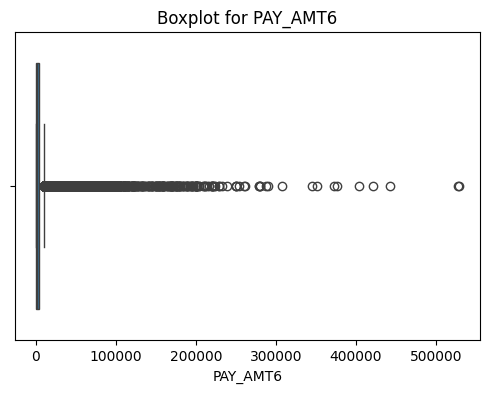

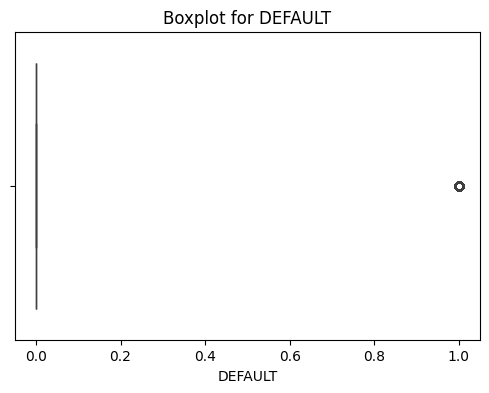

In [27]:
#BOX PLOT FOR DETECT OUTLIERS
for column in df.select_dtypes(include=np.number).columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[column])
    plt.title(f"Boxplot for {column}")
    plt.show()

Handling the outliers

In [28]:
#CAPPING THE OUTLIERS
num_cols = ['LIMIT_BAL', 'AGE', 'BILL_AMT1','BILL_AMT2','BILL_AMT3',
            'BILL_AMT4','BILL_AMT5','BILL_AMT6',
            'PAY_AMT1','PAY_AMT2','PAY_AMT3',
            'PAY_AMT4','PAY_AMT5','PAY_AMT6']
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    df[col] = np.clip(df[col], Q1, Q3)

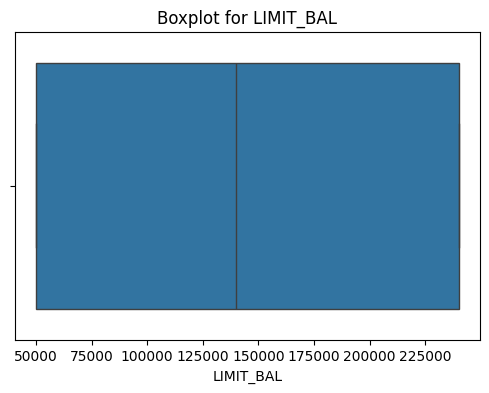

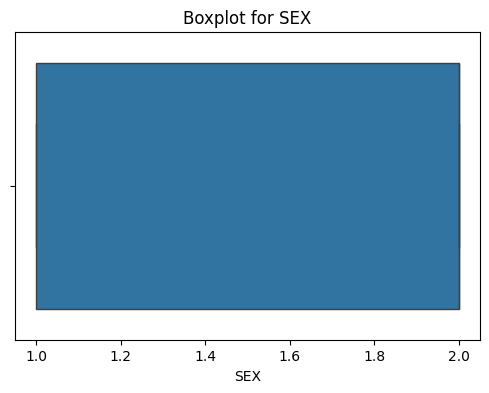

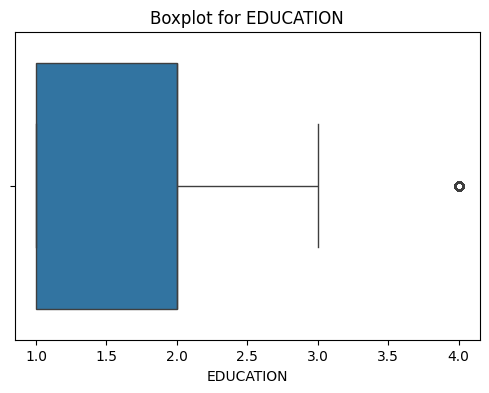

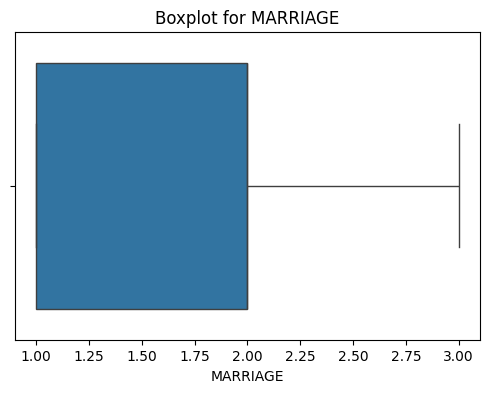

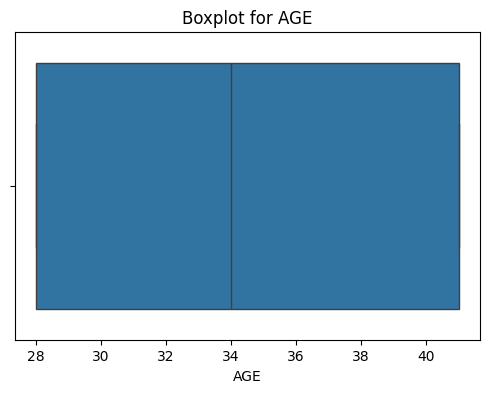

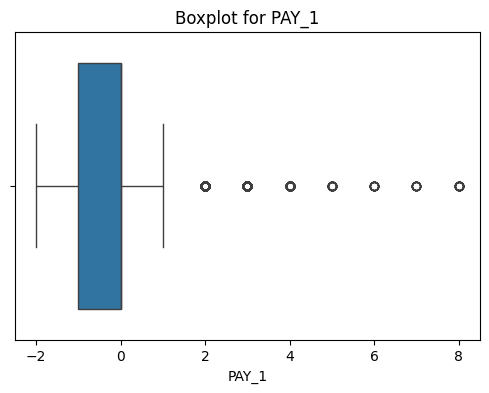

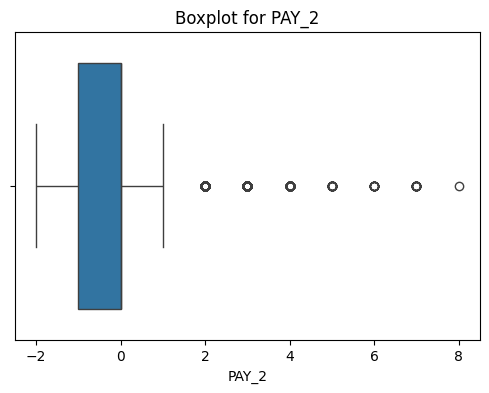

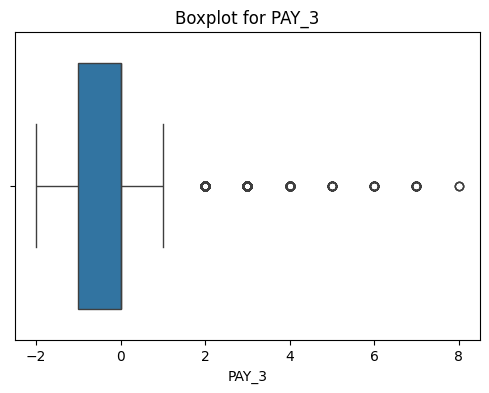

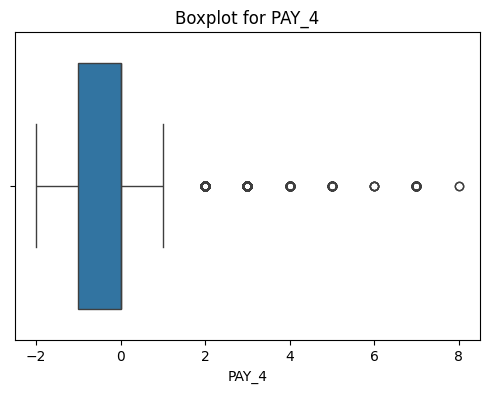

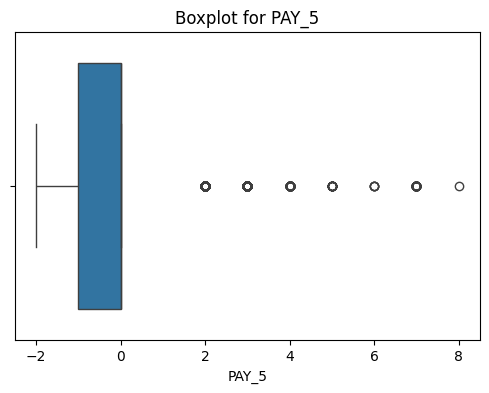

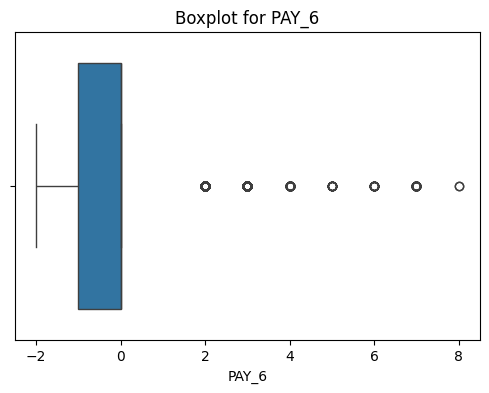

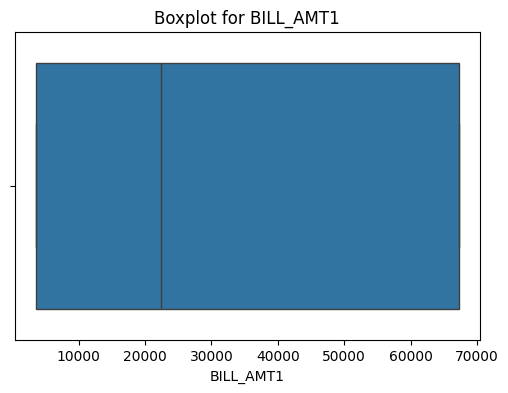

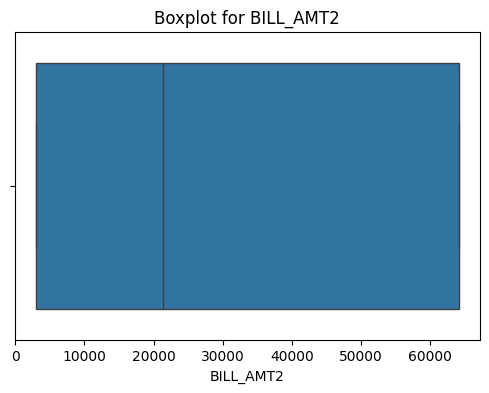

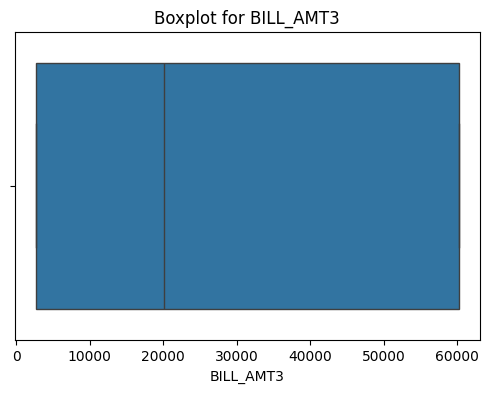

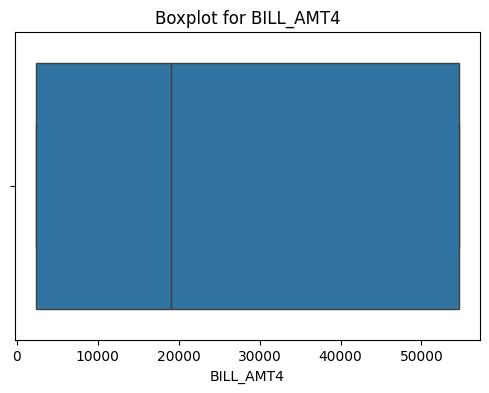

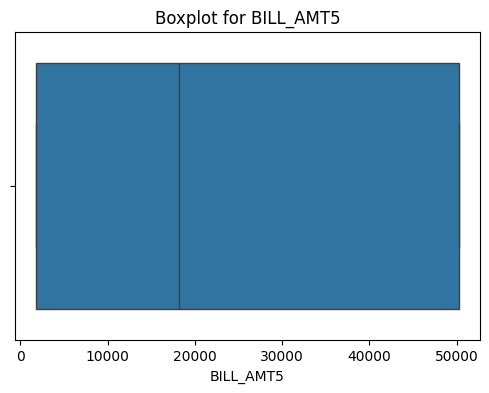

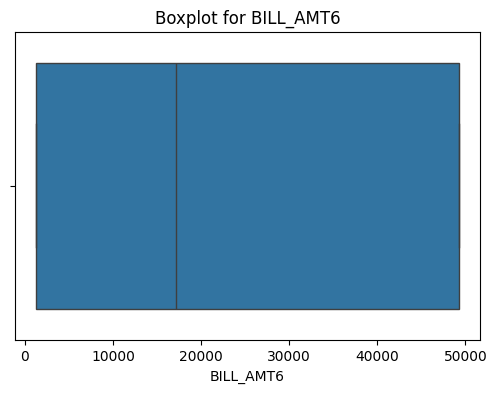

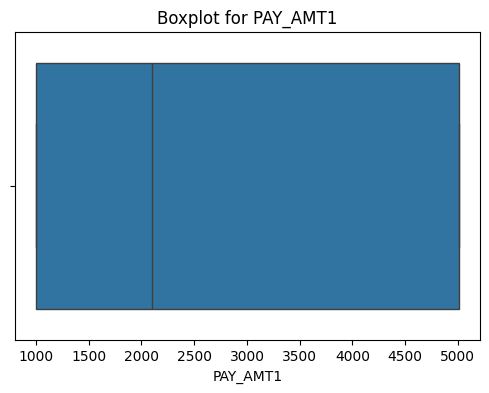

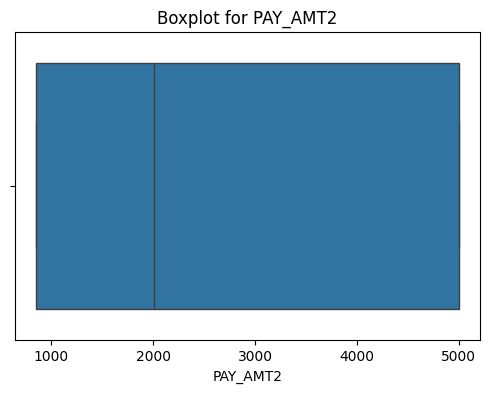

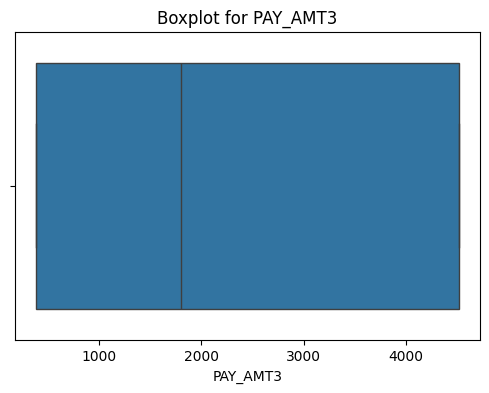

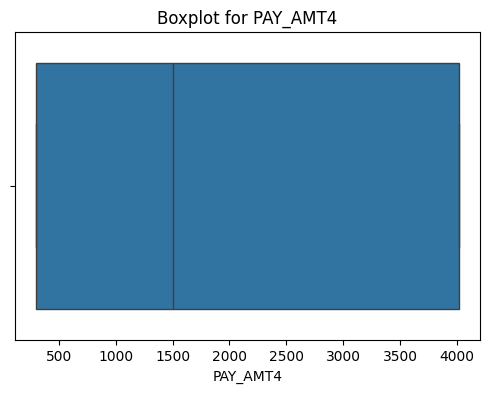

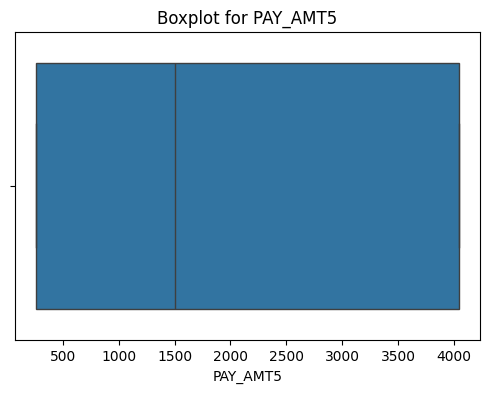

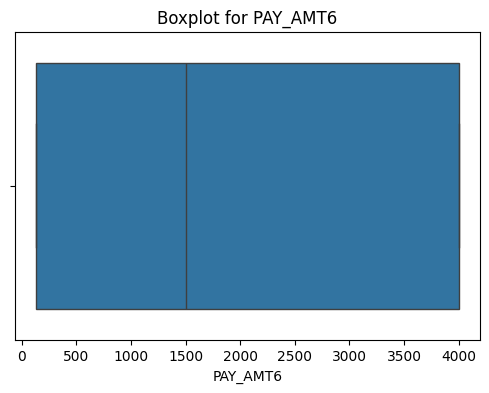

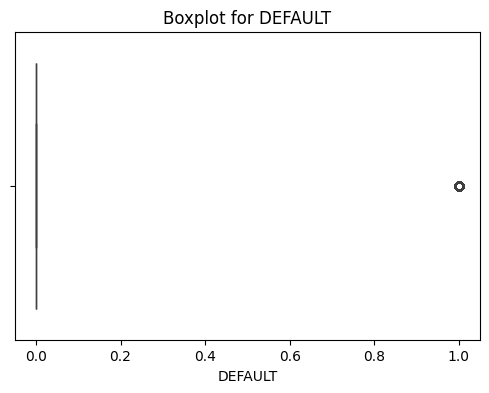

In [29]:
for column in df.select_dtypes(include=np.number).columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[column])
    plt.title(f"Boxplot for {column}")
    plt.show()

In [30]:
df['DEFAULT'].value_counts()

,count
DEFAULT,
0,23335
1,6630


**Feature scaling**

In [31]:
df=df[['LIMIT_BAL', 'AGE', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5',
       'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4',
       'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3',
       'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6','DEFAULT']]

In [32]:
df

,LIMIT_BAL,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,50000,28,2,2,-1,-1,-2,-2,3913,3102,...,2360,1787,1262,1000,850,390,300,261,131,1
1,120000,28,-1,2,0,0,0,2,3595,3010,...,3272,3455,3261,1000,1000,1000,1000,261,2000,1
2,90000,34,0,0,0,0,0,0,29239,14027,...,14331,14948,15549,1518,1500,1000,1000,1000,4000,0
3,50000,37,0,0,0,0,0,0,46990,48233,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,41,-1,0,-1,0,0,0,8617,5670,...,20940,19146,19131,2000,5000,4512,4016,689,679,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000,39,0,0,0,0,0,0,67260,64109,...,54601,31237,15980,5008,5000,4512,3047,4042,1000,0
29996,150000,41,-1,-1,-1,-1,0,0,3595,3010,...,8979,5190,1262,1837,3526,4512,300,261,131,0
29997,50000,37,4,3,2,-1,0,0,3595,3356,...,20878,20582,19357,1000,850,4512,4016,2000,3100,1
29998,80000,41,1,-1,0,0,0,-1,3595,64109,...,52774,11855,48944,5008,3409,1178,1926,4042,1804,1


In [33]:
df_0=df[df['DEFAULT']==0]
df_1=df[df['DEFAULT']==1]

# Ensure we don't try to sample more rows than available
# For df_0, if it has less than 7000 rows, sample all of them. Otherwise, sample 7000.
n_df0 = min(5000, len(df_0))
df_0 = df_0.sample(n=n_df0, random_state=42)

# For df_1, if it has less than 6600 rows, sample all of them. Otherwise, sample 6600.
n_df1 = min(6600, len(df_1))
df_1 = df_1.sample(n=n_df1, random_state=42)

df=pd.concat([df_0,df_1],axis=0)
df['DEFAULT'].value_counts()

,count
DEFAULT,
1,6600
0,5000


**Train model**

In [34]:
X = df.drop(columns=['DEFAULT'])
y = df['DEFAULT']

In [35]:
#TRAIN MODEL
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [36]:
X_train

,LIMIT_BAL,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
24544,50000,41,0,0,2,2,0,0,13543,16434,17452,16879,17059,17263,3132,1577,390,757,628,700
21262,50000,41,1,-2,-2,-2,-2,-2,3595,3010,2711,2360,1787,1262,1000,850,390,300,261,131
9619,240000,37,-2,-2,-2,-2,-2,-2,3595,3010,2711,2360,1787,1262,1000,850,390,300,261,131
23943,50000,28,0,0,2,3,2,2,14068,16706,18342,17755,17967,17538,3200,2200,390,800,261,1401
8766,50000,28,0,0,0,0,0,0,15703,17140,18127,18605,16351,16928,2000,1600,1030,1000,1000,1000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17358,120000,41,2,2,3,2,2,3,25809,29366,28615,29347,30868,30099,4300,850,1500,2300,261,131
26184,240000,38,-2,-2,-2,-2,-2,-2,3595,3010,2711,2360,1787,1262,1000,850,390,390,390,390
22768,60000,41,-1,0,0,0,0,0,63236,64109,60201,54601,47317,48726,2500,3000,2292,1526,2000,2000
15158,50000,28,0,0,0,0,-1,0,14617,17363,20430,25130,7746,10583,3000,3376,4512,4016,4042,3023


In [37]:
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

In [38]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_std = X_train.copy()
X_test_std = X_test.copy()

X_train_std['LIMIT_BAL'] = scaler.fit_transform(X_train['LIMIT_BAL'].values.reshape(-1, 1))
X_test_std['LIMIT_BAL'] = scaler.transform(X_test['LIMIT_BAL'].values.reshape(-1, 1))
X_train_std['AGE'] = scaler.fit_transform(X_train['AGE'].values.reshape(-1, 1))
X_test_std['AGE'] = scaler.transform(X_test['AGE'].values.reshape(-1, 1))
for i in range(1,7):
    X_train_std['PAY_' + str(i)] = scaler.fit_transform(X_train['PAY_' + str(i)].values.reshape(-1, 1))
    X_test_std['PAY_' + str(i)] = scaler.transform(X_test['PAY_' + str(i)].values.reshape(-1, 1))
    X_train_std['BILL_AMT' + str(i)] = scaler.fit_transform(X_train['BILL_AMT' + str(i)].values.reshape(-1, 1))
    X_test_std['BILL_AMT' + str(i)] = scaler.transform(X_test['BILL_AMT' + str(i)].values.reshape(-1, 1))
    X_train_std['PAY_AMT' + str(i)] = scaler.fit_transform(X_train['PAY_AMT' + str(i)].values.reshape(-1, 1))
    X_test_std['PAY_AMT' + str(i)] = scaler.transform(X_test['PAY_AMT' + str(i)].values.reshape(-1, 1))

In [39]:
X_train=X_train_std
X_test=X_test_std

**Balance the class**

In [40]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
class_weights=compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)

**LOGISTIC REGRESSION**

In [41]:
#LOGISTIC REGRESSION
from sklearn.linear_model import LogisticRegression

# Convert class_weights array to a dictionary
class_weights_dict = {0: class_weights[0], 1: class_weights[1]}

lr = LogisticRegression(C=1,class_weight=class_weights_dict,penalty='l1',solver='saga',max_iter=1000)
lr.fit(X_train, y_train)

LogisticRegression(C=1,
                   class_weight={0: np.float64(1.1690602166792643),
                                 1: np.float64(0.8736584447373376)},
                   max_iter=1000, penalty='l1', solver='saga')

In [42]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
pred_LR = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred_LR))

Accuracy: 0.6637931034482759


In [43]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression

# Parameter grid
param_grid_lr = {
    #'C':[0.001,0.1,1,5],
    #'solver':['liblinear']
    'C': [0.1, 0.1, 1, 10,20,30,100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'class_weight': ['balanced']
}

# Model
lr = LogisticRegression(max_iter=1000,class_weight=class_weights_dict)

# Grid Search
grid_lr = RandomizedSearchCV(lr, param_grid_lr, cv=5, scoring='accuracy', n_jobs=-1)
grid_lr.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", grid_lr.best_params_)

Best Parameters: {'solver': 'saga', 'penalty': 'l1', 'class_weight': 'balanced', 'C': 0.1}


In [44]:
best_lr = grid_lr.best_estimator_
best_lr.fit(X_train, y_train)

LogisticRegression(C=0.1, class_weight='balanced', max_iter=1000, penalty='l1',
                   solver='saga')

In [45]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred_lr = best_lr.predict(X_test)
# y_prob_lr = best_lr.predict_proba(X_test)[:,1]
# y_pred_lr = (y_prob_lr > 0.).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.6672413793103448
[[723 308]
 [464 825]]
              precision    recall  f1-score   support

           0       0.61      0.70      0.65      1031
           1       0.73      0.64      0.68      1289

    accuracy                           0.67      2320
   macro avg       0.67      0.67      0.67      2320
weighted avg       0.68      0.67      0.67      2320



**RANDOM FOREST**

In [46]:
#RANDOM FOREST
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, max_depth=10 ,class_weight=class_weights_dict)
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight={0: np.float64(1.1690602166792643),
                                     1: np.float64(0.8736584447373376)},
                       max_depth=10)

In [47]:
pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred_rf))

Accuracy: 0.7068965517241379


In [48]:
#Hyperparameter tunnig for Randomforest
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

params = {
    'n_estimators': [50,100, 200],
    'max_depth': [5,10,15],
    'min_samples_split': [2,5,10]
}

grid_rf = RandomizedSearchCV(RandomForestClassifier(class_weight=class_weights_dict), params, cv=5)
grid_rf.fit(X_train, y_train)

best_model = grid_rf.best_estimator_
print("Best Parameters:", grid_rf.best_params_)

Best Parameters: {'n_estimators': 100, 'min_samples_split': 2, 'max_depth': 10}


In [49]:
#EVALUATION METRIC for Random forest
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred_rf = best_model.predict(X_test)
# y_prob_rf = rf.predict_proba(X_test)[:,1]
# y_pred_rf = (y_prob_rf > 0.3).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7086206896551724
[[785 246]
 [430 859]]
              precision    recall  f1-score   support

           0       0.65      0.76      0.70      1031
           1       0.78      0.67      0.72      1289

    accuracy                           0.71      2320
   macro avg       0.71      0.71      0.71      2320
weighted avg       0.72      0.71      0.71      2320



In [50]:
y_train.value_counts()

,count
DEFAULT,
1,5311
0,3969


In [51]:

y_test.value_counts()

,count
DEFAULT,
1,1289
0,1031


**DICISION TREE**

In [52]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(max_depth=8, class_weight=class_weights_dict)
dt.fit(X_train, y_train)

DecisionTreeClassifier(class_weight={0: np.float64(1.1690602166792643),
                                     1: np.float64(0.8736584447373376)},
                       max_depth=8)

In [53]:
pred_dt = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred_dt))

Accuracy: 0.6831896551724138


In [54]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
param_grid = {
    'max_depth':[3,5,10],
    'min_samples_split':[2,5,10],
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 10, 15, 20],
    #'min_samples_split': [2, 5, 10, 20],
    # 'min_samples_leaf': [1, 2, 5, 10],
    'max_features': ['sqrt', 'log2', None],
    'class_weight': [None, 'balanced']
}

dt = DecisionTreeClassifier(random_state=42,class_weight=class_weights_dict)

grid_dt = RandomizedSearchCV(dt, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_dt.fit(X_train, y_train)

print("Best Parameters:", grid_dt.best_params_)

Best Parameters: {'min_samples_split': 10, 'max_features': 'sqrt', 'max_depth': 3, 'criterion': 'entropy', 'class_weight': None}


In [55]:
best_dt = grid_dt.best_estimator_
best_dt.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, max_features='sqrt',
                       min_samples_split=10, random_state=42)

In [56]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred_dt = best_dt.predict(X_test)
# y_prob_dt = best_dt.predict_proba(X_test)[:,1]
# y_pred_dt = (y_prob_dt > 0.6).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.6392241379310345
[[544 487]
 [350 939]]
              precision    recall  f1-score   support

           0       0.61      0.53      0.57      1031
           1       0.66      0.73      0.69      1289

    accuracy                           0.64      2320
   macro avg       0.63      0.63      0.63      2320
weighted avg       0.64      0.64      0.64      2320



**XGBOOST CLASSIFIER**

In [57]:
#XGBoost classifier
from xgboost import XGBClassifier
from collections import Counter

# Count class distribution
counter = Counter(y_train)
neg, pos = counter[0], counter[1]

# Calculate scale_pos_weight
scale_pos_weight = neg / pos

xgb = XGBClassifier(n_estimators=200, learning_rate=0.09,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',  # avoid warning
    use_label_encoder=False
)
xgb.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:39:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.09, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [58]:
pred_xgb = xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred_xgb))

Accuracy: 0.694396551724138


In [59]:
param_grid = {
    'learning_rate':[0.01,0.1,0.6,0.8],
    'max_depth':[3,6,10,15],
    'n_estimators':[100,200,250,300]
}
xgb = XGBClassifier(scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',  # avoid warning
    use_label_encoder=False)
grid_xgb = RandomizedSearchCV(xgb, param_grid, cv=5, scoring='f1', n_jobs=-1)

grid_xgb.fit(X_train, y_train)

print("Best Parameters:", grid_xgb.best_params_)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:41:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters: {'n_estimators': 250, 'max_depth': 15, 'learning_rate': 0.01}


In [60]:
best_xgb = grid_xgb.best_estimator_
best_xgb.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:41:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=15, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=250, n_jobs=None,
              num_parallel_tree=None, ...)

In [61]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred_xgb = best_xgb.predict(X_test)
# y_prob_xg = best_xgb.predict_proba(X_test)[:,1]
# y_pred_xgb = (y_prob_xg > 0.4).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.6814655172413793
[[702 329]
 [410 879]]
              precision    recall  f1-score   support

           0       0.63      0.68      0.66      1031
           1       0.73      0.68      0.70      1289

    accuracy                           0.68      2320
   macro avg       0.68      0.68      0.68      2320
weighted avg       0.68      0.68      0.68      2320



**SVC**

In [62]:
from sklearn.svm import SVC

svm = SVC(class_weight=class_weights_dict)
svm.fit(X_train, y_train)

SVC(class_weight={0: np.float64(1.1690602166792643),
                  1: np.float64(0.8736584447373376)})

In [63]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred_svm = svm.predict(X_test)


print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(confusion_matrix(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

Accuracy: 0.7038793103448275
[[797 234]
 [453 836]]
              precision    recall  f1-score   support

           0       0.64      0.77      0.70      1031
           1       0.78      0.65      0.71      1289

    accuracy                           0.70      2320
   macro avg       0.71      0.71      0.70      2320
weighted avg       0.72      0.70      0.70      2320



**Naive bias**

In [64]:
from sklearn.naive_bayes import BernoulliNB
from sklearn.model_selection import GridSearchCV

In [65]:
param_grid = {
    'alpha': [0.01, 0.1, 0.5, 1.0, 2.0],
    'binarize': [None, 0.0, 0.5, 1.0],
    'fit_prior': [True, False]
}

In [66]:
bnb = BernoulliNB()

grid = GridSearchCV(
    estimator=bnb,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=BernoulliNB(), n_jobs=-1,
             param_grid={'alpha': [0.01, 0.1, 0.5, 1.0, 2.0],
                         'binarize': [None, 0.0, 0.5, 1.0],
                         'fit_prior': [True, False]},
             scoring='accuracy')

In [67]:
print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Params: {'alpha': 0.01, 'binarize': 0.5, 'fit_prior': True}
Best Score: 0.6753232758620691


In [68]:
best_model_nb= grid.best_estimator_

y_pred_nb = best_model_nb.predict(X_test)

In [69]:
print(classification_report(y_test, y_pred_nb))
print(confusion_matrix(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       0.62      0.71      0.67      1031
           1       0.74      0.66      0.70      1289

    accuracy                           0.68      2320
   macro avg       0.68      0.68      0.68      2320
weighted avg       0.69      0.68      0.68      2320

[[735 296]
 [443 846]]


**KNN**

In [70]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [71]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier
pram_grid = {
    'n_neighbors': [3,5,7,9],
    'weights': ['uniform', 'distance'],
    'p': [1,2]
}


grid_knn = RandomizedSearchCV(knn, pram_grid, cv=5, scoring='f1', n_jobs=-1)

grid_knn.fit(X_train, y_train)
print("Best Parameters:", grid_knn.best_params_)

Best Parameters: {'weights': 'uniform', 'p': 1, 'n_neighbors': 9}


In [72]:
best_knn = grid_knn.best_estimator_
best_knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=9, p=1)

In [73]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred_knn = best_knn.predict(X_test)
# y_prob_knn = best_knn.predict_proba(X_test)[:,1]
# y_pred_knn = (y_prob_knn > 0.3).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print(confusion_matrix(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

Accuracy: 0.6689655172413793
[[615 416]
 [352 937]]
              precision    recall  f1-score   support

           0       0.64      0.60      0.62      1031
           1       0.69      0.73      0.71      1289

    accuracy                           0.67      2320
   macro avg       0.66      0.66      0.66      2320
weighted avg       0.67      0.67      0.67      2320



**Light GBM**

In [74]:
from lightgbm import LGBMClassifier
lgbm = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=-1,       # no limit
    num_leaves=31,      # controls complexity
    random_state=42,
    class_weight=class_weights_dict
)

# Train
lgbm.fit(X_train, y_train)

# Predict
y_pred_lgbm = lgbm.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred_lgbm))

[LightGBM] [Info] Number of positive: 5311, number of negative: 3969
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002303 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3158
[LightGBM] [Info] Number of data points in the train set: 9280, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Accuracy: 0.7081896551724138


In [75]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred_lgbm = lgbm.predict(X_test)
# y_prob_lgb = lgbm.predict_proba(X_test)[:,1]
# y_pred_lgbm = (y_prob_lgb > 0.4).astype(int)
print("Accuracy:", accuracy_score(y_test, y_pred_lgbm))
print(confusion_matrix(y_test, y_pred_lgbm))
print(classification_report(y_test, y_pred_lgbm))

Accuracy: 0.7081896551724138
[[761 270]
 [407 882]]
              precision    recall  f1-score   support

           0       0.65      0.74      0.69      1031
           1       0.77      0.68      0.72      1289

    accuracy                           0.71      2320
   macro avg       0.71      0.71      0.71      2320
weighted avg       0.71      0.71      0.71      2320



In [76]:
print("Accuracy of LR : ", accuracy_score(y_test, pred_LR))
print("Accuracy of RF : ", accuracy_score(y_test, y_pred_rf))
print("Accuracy of DT : ", accuracy_score(y_test, y_pred_dt))
print("Accuracy of XGB : ", accuracy_score(y_test, y_pred_xgb))
print("Accuracy of SVM : ", accuracy_score(y_test, y_pred_svm))
print("Accuracy of NB : ", accuracy_score(y_test, y_pred_nb))
print("Accuracy of KNN : ", accuracy_score(y_test, y_pred_knn))
print("Accuracy of LGBM : ", accuracy_score(y_test, y_pred_lgbm))

Accuracy of LR :  0.6637931034482759
Accuracy of RF :  0.7086206896551724
Accuracy of DT :  0.6392241379310345
Accuracy of XGB :  0.6814655172413793
Accuracy of SVM :  0.7038793103448275
Accuracy of NB :  0.6814655172413793
Accuracy of KNN :  0.6689655172413793
Accuracy of LGBM :  0.7081896551724138


In [92]:
# Models dictionary
models = {
    "Logistic Regression": best_lr,
    "Decision Tree": dt,
    "Random Forest": best_model,
    "Naive Bayes": best_model_nb,
    "KNN": best_knn,
    "XGBoost": best_xgb,
    "SVM": svm,
    "LightGBM": lgbm
}

# Train and evaluate
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    results.append([name, acc])
    print(f"{name}: {acc:.4f}")

# Convert results to DataFrame
results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])

# Sort results
results_df = results_df.sort_values(by="Accuracy", ascending=False)

print("\nBest Model:")
print(results_df)

Logistic Regression: 0.6672
Decision Tree: 0.6353
Random Forest: 0.7082
Naive Bayes: 0.6815
KNN: 0.6690


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:46:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost: 0.6815
SVM: 0.7039
[LightGBM] [Info] Number of positive: 5311, number of negative: 3969
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000675 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3158
[LightGBM] [Info] Number of data points in the train set: 9280, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
LightGBM: 0.7082

Best Model:
                 Model  Accuracy
2        Random Forest  0.708190
7             LightGBM  0.708190
6                  SVM  0.703879
3          Naive Bayes  0.681466
5              XGBoost  0.681466
4                  KNN  0.668966
0  Logistic Regression  0.667241
1        Decision Tree  0.635345


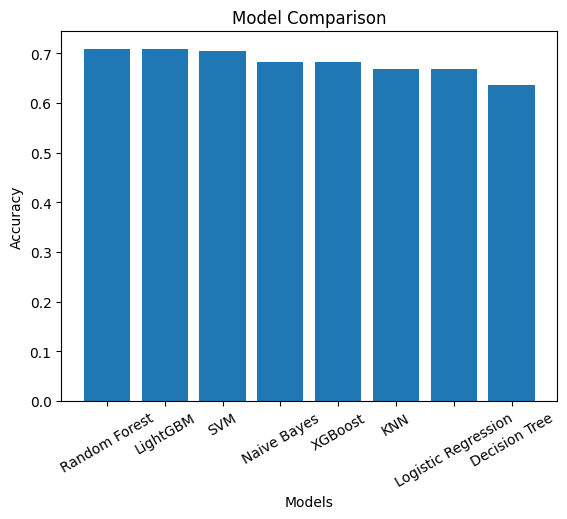

In [93]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.xticks(rotation=30)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()

In [77]:
input0 = [[
    20000, 24,
    2, 2, 2, 2, 2, 2,
    90000, 95000, 100000, 105000, 110000, 120000,
    1000, 1000, 500, 500, 300, 200
]]

In [78]:
input1 = [[
    300000, 40,
    0, 0, 0, 0, 0, 0,
    60000, 55000, 50000, 48000, 45000, 40000,
    25000, 25000, 25000, 25000, 25000, 25000
]]

In [79]:
input2 = [[
    120000, 29,
    0, 0, 0, 0, 0, 0,
    30000, 28000, 26000, 25000, 24000, 22000,
    12000, 12000, 12000, 12000, 12000, 12000
]]

In [80]:
input3 = [[
    80000, 35,
    0, 0, 0, 0, 0, 0,
    10000, 9000, 8000, 7000, 6000, 5000,
    8000, 8000, 8000, 8000, 8000, 8000
]]

In [81]:
input4 = [[
    500000,  45,
    -1, 0, -1, 0, -1, -1,
    100000, 95000, 90000, 85000, 80000, 75000,
    40000, 40000, 40000, 40000, 40000, 40000
]]

In [82]:
input5 = [[
    100000,  26,
    0, 0, 0, 0, 0, 0,
    20000, 18000, 17000, 16000, 15000, 14000,
    10000, 10000, 10000, 10000, 10000, 10000
]]

In [83]:
input6 = [[
    20000,  24,
    2, 2, 2, 2, 2, 2,
    90000, 95000, 100000, 105000, 110000, 120000,
    1000, 1000, 500, 500, 300, 200
]]

In [84]:
input7 = [[
    50000,  27,
    3, 2, 2, 2, 1, 1,
    70000, 72000, 75000, 78000, 80000, 82000,
    2000, 1500, 1000, 800, 500, 300
]]

In [85]:
input8 = [[
    80000,  33,
    2, 2, 1, 1, 2, 2,
    120000, 125000, 130000, 135000, 140000, 150000,
    0, 0, 0, 0, 0, 0
]]

In [86]:
input9 = [[
    60000,  30,
    1, 2, 3, 2, 2, 2,
    80000, 85000, 90000, 95000, 100000, 110000,
    3000, 2000, 1500, 1000, 800, 500
]]

In [87]:
input10 = [[
    10000, 22,
    2, 2, 2, 2, 2, 2,
    50000, 52000, 55000, 58000, 60000, 65000,
    500, 500, 400, 300, 200, 100
]]

In [96]:
inputs = [input0,input1, input2, input3, input4, input5,input6, input7, input8, input9, input10]

for i, data in enumerate(inputs, 1):
    pred = best_model.predict(data)
    print(f"Input {i}: {'Non-Defaulter' if pred[0]==0 else 'Defaulter'}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local

Input 1: Defaulter
Input 2: Non-Defaulter
Input 3: Non-Defaulter
Input 4: Non-Defaulter
Input 5: Non-Defaulter
Input 6: Non-Defaulter
Input 7: Defaulter
Input 8: Defaulter
Input 9: Defaulter
Input 10: Defaulter
Input 11: Defaulter


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [89]:
input_data = [
    [25000,  23, 2, 2, 2, 2, 2, 2, 80000, 82000, 85000, 88000, 90000, 92000, 1000, 800, 600, 500, 400, 300],

    [40000,  28, 0, 0, 0, -1, 0 ,0 ,70000, 75000, 78000, 80000, 82000, 85000, 1500, 1200, 1000, 800, 600, 500],

    [60000,  35, 0, 3, 0, 0, 2, 2, 90000, 95000, 100000, 105000, 110000, 115000, 2000, 1500, 1200, 1000, 800, 600],

    [15000,  22, 2, 0, 2, 0, 2, 2, 50000, 52000, 55000, 58000, 60000, 62000, 500, 400, 300, 200, 150, 100],

    [50000,  40, 1, 2, 3, 2, 2, 2, 85000, 88000, 90000, 95000, 100000, 105000, 3000, 2000, 1500, 1200, 1000, 800]]

In [90]:
predictions = best_model.predict(input_data)

for i, pred in enumerate(predictions, 1):
    print(f"Input {i}: {'Defaulter' if pred==1 else 'Non-Defaulter'}")

Input 1: Defaulter
Input 2: Non-Defaulter
Input 3: Defaulter
Input 4: Defaulter
Input 5: Defaulter


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [91]:
# import pickle
# pickle.dump(best_model_nb, open("best_nb_model.pkl", "wb"))
